# House Price Prediction using Linear Regression

**Track:** Data Analytics (Level 2) | **Internship:** Oasis Infobyte SIP | **Author:** Shreya Kadam

**Objective:** Predict house prices using Linear Regression based on RM (rooms), LSTAT (% lower-status population), and PTRATIO (pupil-teacher ratio).

**Dataset:** Housing dataset (Boston Housing, reduced) — target variable: MEDV (median house price)

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

In [24]:
df=pd.read_csv("housing.csv")
df

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0
...,...,...,...,...
484,6.593,9.67,21.0,470400.0
485,6.120,9.08,21.0,432600.0
486,6.976,5.64,21.0,501900.0
487,6.794,6.48,21.0,462000.0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [26]:
df.shape

(489, 4)

In [27]:
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [28]:
df.describe

<bound method NDFrame.describe of         RM  LSTAT  PTRATIO      MEDV
0    6.575   4.98     15.3  504000.0
1    6.421   9.14     17.8  453600.0
2    7.185   4.03     17.8  728700.0
3    6.998   2.94     18.7  701400.0
4    7.147   5.33     18.7  760200.0
..     ...    ...      ...       ...
484  6.593   9.67     21.0  470400.0
485  6.120   9.08     21.0  432600.0
486  6.976   5.64     21.0  501900.0
487  6.794   6.48     21.0  462000.0
488  6.030   7.88     21.0  249900.0

[489 rows x 4 columns]>

In [29]:
df.isnull().sum()

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

In [30]:
df.columns  

Index(['RM', 'LSTAT', 'PTRATIO', 'MEDV'], dtype='str')

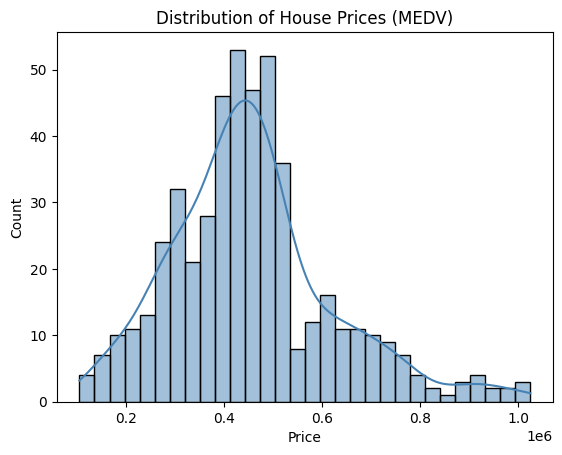

In [31]:
sns.histplot(df["MEDV"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("Price")
plt.show()

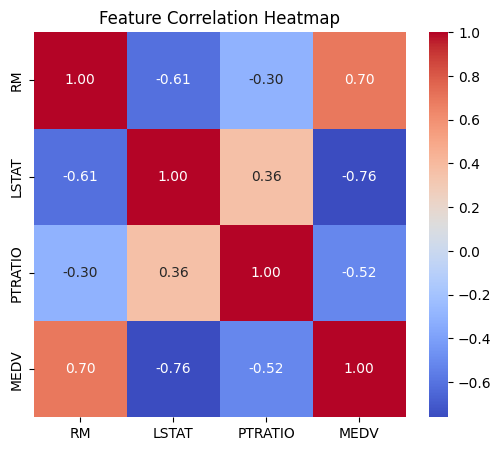

In [32]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Selection

This dataset contains 3 predictor features:
- **RM** — average number of rooms per dwelling (higher RM → typically higher price)
- **LSTAT** — % of lower-status population in the area (higher LSTAT → typically lower price)
- **PTRATIO** — pupil-teacher ratio by town (higher ratio → typically lower price, as it can indicate less-funded schools)

The correlation heatmap above confirms these relationships: RM should show a positive correlation with MEDV, while LSTAT and PTRATIO should show negative correlations. No categorical features are present in this reduced dataset, so no encoding is needed. No missing values were found either (confirmed by `df.isnull().sum()`).

In [33]:
x=df.drop('MEDV',axis=1) #here we remove the MEDV column means on x line only contains input variables hence we remove MEDV that is a output variable in Machine learning x axis contains input variable and y contains output variable means what we want to predict
y=df['MEDV'] #y axis contains output variable means what we want to predict

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size= 0.2, random_state=42) #if we do not use random_state, every time we run the program the split will change.

In [35]:
model=LinearRegression()

In [36]:
model.fit(x_train,y_train) #fit() trains the model and Finds the best line that fits the data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
y_pred=model.predict(x_test) #predict() generates predicted values and Uses testing data.

In [38]:
mse=mean_squared_error(y_test,y_pred) #y_test is the Actual value from the dataset and here we calculating the error means the square of difference between actual value and the predicted value by model
print("MSE:",mse)

MSE: 6789025559.26589


In [39]:
rmse = np.sqrt(mse) #Root of mean square error
print("RMSE:", rmse)

RMSE: 82395.54332162565


In [40]:
mae = mean_absolute_error(y_test, y_pred) #In Absolute error there is no square of differnce
print("MAE:", mae)

MAE: 64277.28865670337


In [41]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.6910934003098511


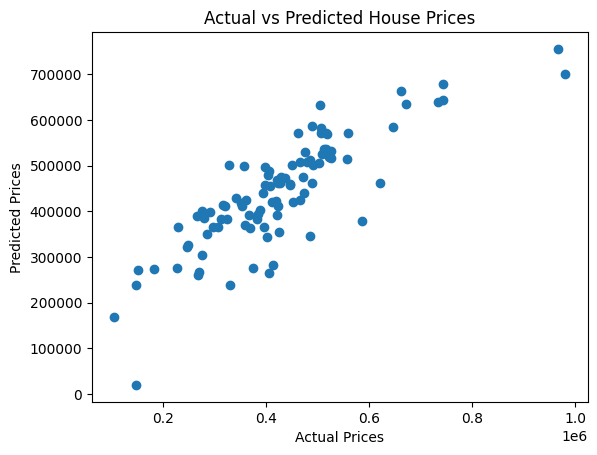

In [40]:
plt.scatter(y_test, y_pred) #Scatter = many dots scattered on the graph, scatter() = a function in Matplotlib used to create that graph, Scatter plot = a type of graph that is used to represent the relation between two variables
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

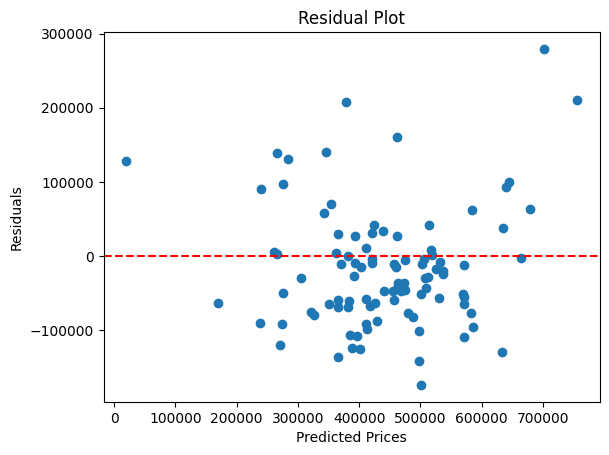

In [42]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [43]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients

,Feature,Coefficient
0,RM,87322.203619
1,LSTAT,-10620.637315
2,PTRATIO,-19324.410296


## Coefficient Interpretation

Based on the coefficients table above:
- A positive coefficient for **RM** means each additional room is associated with an increase in predicted price.
- Negative coefficients for **LSTAT** and **PTRATIO** mean a higher lower-status population percentage and higher pupil-teacher ratios are associated with lower predicted prices.

These results align with the correlation heatmap and match real-world housing market intuition.